In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import cyltransf as ct
from scipy import odr

file_dir = "data100ns-2008"
output_dir = "output"

u_mean = md.Universe(file_dir + "/md_1.tpr", output_dir + "/md_1_mean.xtc")
chains = u_mean.select_atoms("protein").fragments

In [2]:
tot_mol = int((len(chains))/3)
psi = np.zeros(tot_mol)
mean_rad = np.zeros(tot_mol)
# std_rad = np.zeros(tot_mol)
length = np.zeros(tot_mol)
molecules = np.arange(0, tot_mol)

for mol in range(tot_mol):
    molecule = chains[3*mol:3*mol + 3]
    molecule_coords = (molecule[0] + molecule[1]+ molecule[2]).positions
    length[mol] = (molecule_coords[:,2].max() - molecule_coords[:,2].min()) / 10
    psis = np.zeros(3)
    mrads = np.zeros(3)
    for i, chain in enumerate(molecule):
        # Analysis using end2end vector of the backbone atoms of each chain...
        chain_coords = chain.select_atoms("backbone").positions
        chain_filt = ct.remove_ends(0.5, chain_coords) / 10
        rad, phi, z = ct.cyl_proj(chain_filt)
        arc = rad*phi
        atoms_pairs = len(rad) - 1
        darc = np.zeros(atoms_pairs)
        dz = np.zeros(atoms_pairs)
        for a in range(atoms_pairs): # By pairs (consecutive)
            # Get angle with respect with the tangent plane (local cylinder)
            darc[a] = arc[a+1] - arc[a]
            dz[a] = z[a+1] - z[a]
        
        psis[i] = np.rad2deg(np.atan2(np.sum(darc), np.sum(dz)))
        mrads[i] = np.mean(rad)

    mean_rad[mol] = np.mean(mrads)
    psi[mol] = np.mean(psis)

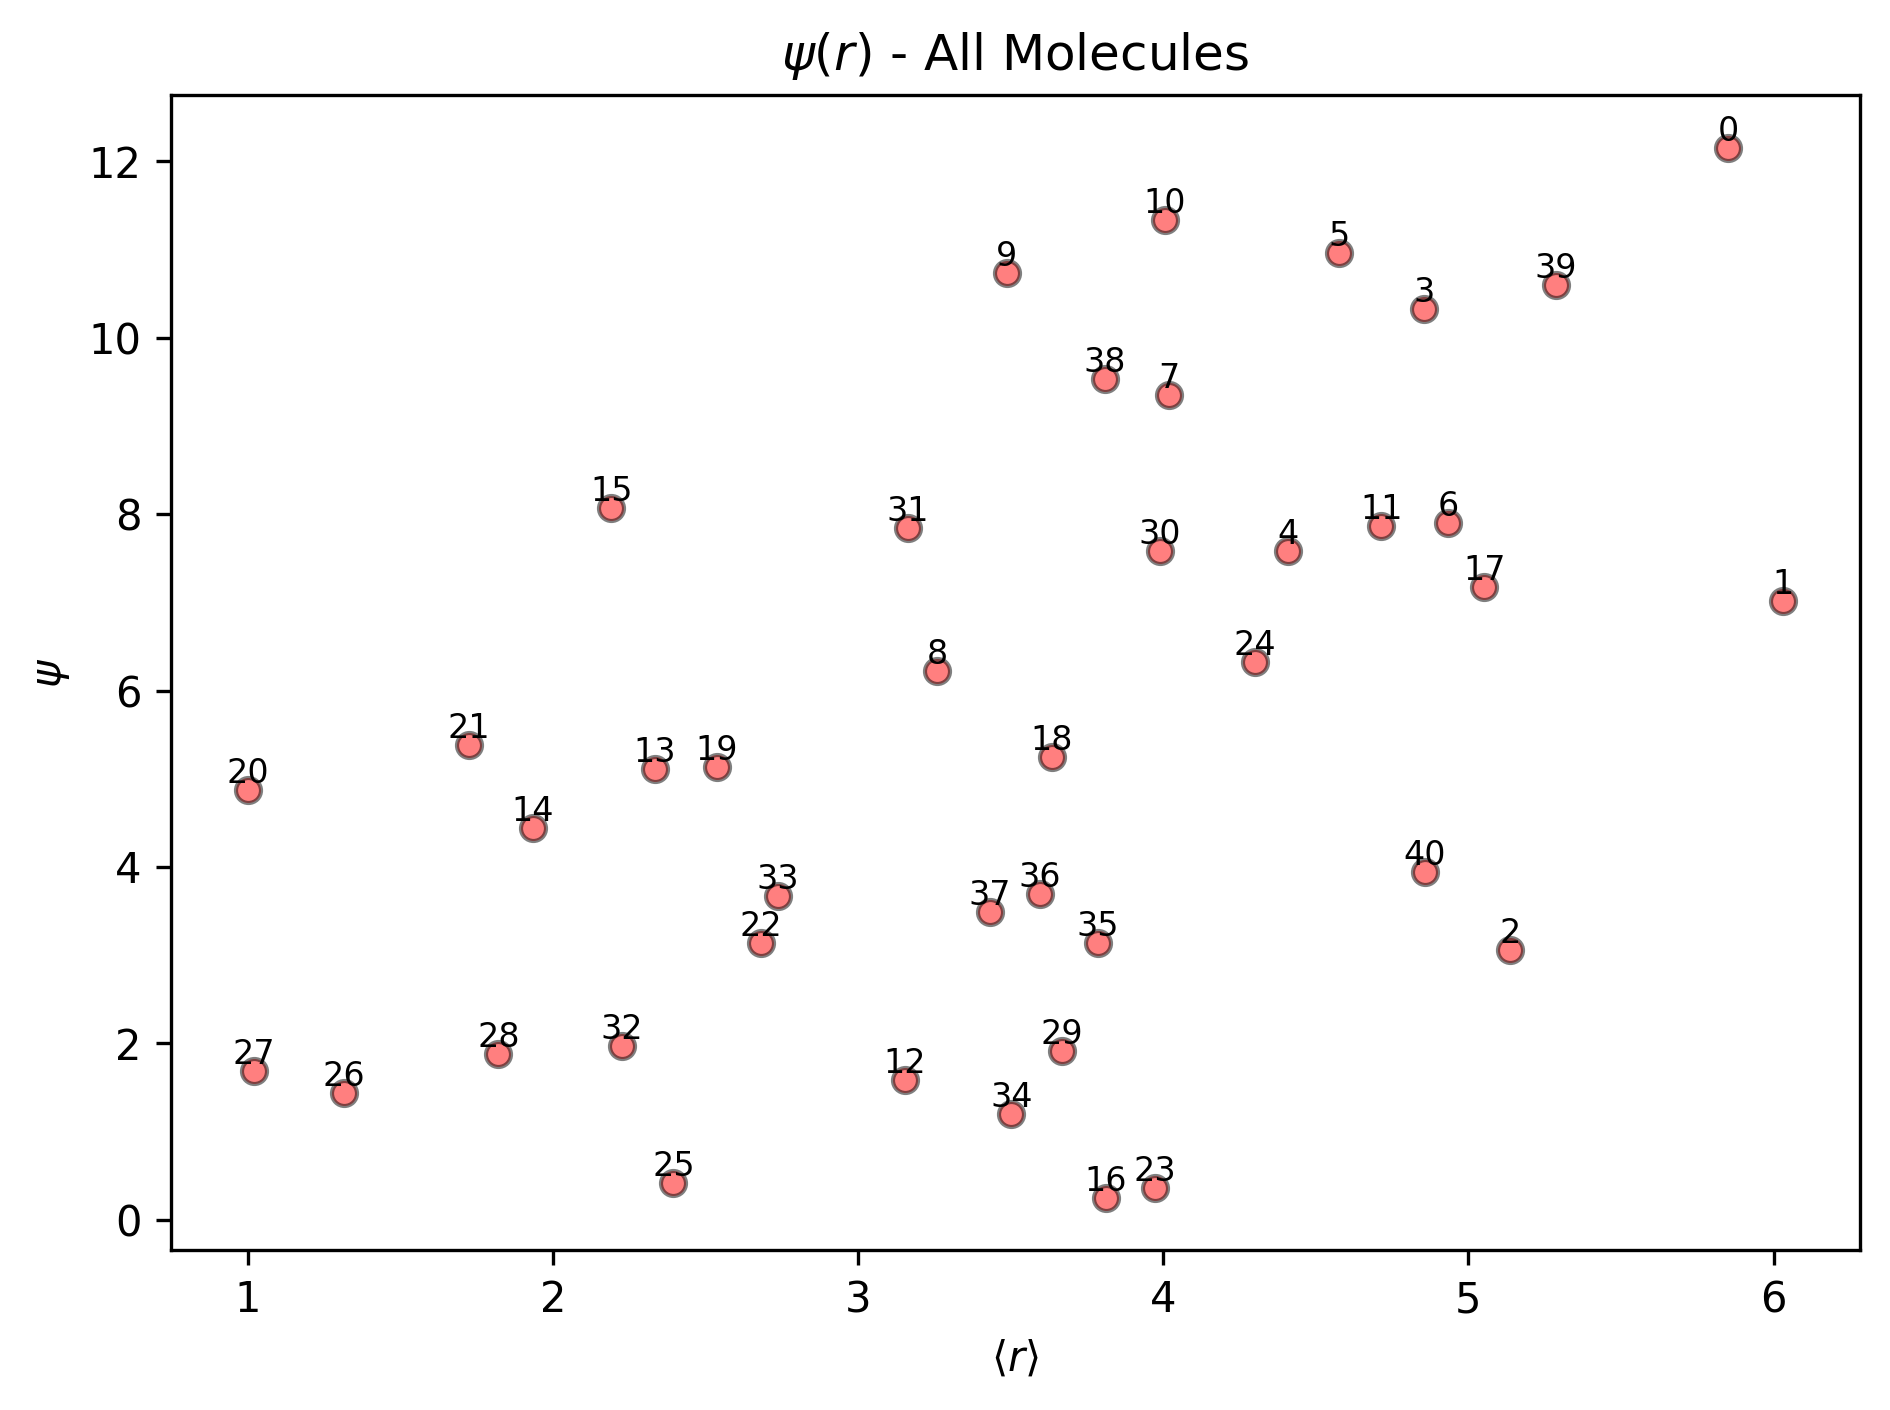

In [7]:
plt.figure(dpi=300)

plt.scatter(mean_rad, abs(psi), color='r', edgecolor='k', alpha=0.5)

# Label Molecules
for i, (x, y) in enumerate(zip(mean_rad, abs(psi))):
    plt.text(x, y, str(i), fontsize=8, ha='center', va='bottom')

plt.xlabel(r'$\langle r \rangle$')
plt.ylabel(r'$\psi$')
plt.title(r"$\psi(r)$ - All Molecules")
plt.tight_layout()
plt.show()